# Labb 2 - Hjärt- och kärlsjukdomar

## Inläsning av dataset

Datasetet `cardio_train.csv`, som innehöll information om hälsa hos individer, lästes in. Målet var att analysera sambandet mellan olika hälsoparametrar och förekomst av hjärt- och kärlsjukdomar (variabeln `cardio`).

Kolumnerna i datasettet skrevs ut för att få en överblick över tillgängliga variabler.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from helpers import (
    print_basic_info,
    calculate_bmi, filter_bmi, categorize_bmi, plot_bmi_distribution,
    filter_blood_pressure, apply_bp_category, plot_cardio_by_category, plot_heatmap, train_all_models, evaluate_models,
    plot_histogram, plot_multiple_cardio_categories, plot_pie_chart, plot_dual_hist_box, create_feature_sets, split_data, scale_data, plot_evaluation_results,
   
)



df = pd.read_csv("../data/cardio_train.csv", sep=";")

# Kolumner printades ut för att ge en överblick över vilka features som fanns.
print(df.columns)
import helpers
print(dir(helpers))


Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')
['ConfusionMatrixDisplay', 'GridSearchCV', 'KNeighborsClassifier', 'LinearSVC', 'LogisticRegression', 'MinMaxScaler', 'Pipeline', 'RandomForestClassifier', 'StandardScaler', 'VotingClassifier', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'accuracy_score', 'apply_bp_category', 'calculate_bmi', 'categorize_blood_pressure', 'categorize_bmi', 'classification_report', 'confusion_matrix', 'count_cardio_cases', 'create_feature_sets', 'create_voting_classifiers', 'evaluate_models', 'evaluate_voting_classifiers', 'extract_best_params', 'filter_blood_pressure', 'filter_bmi', 'get_best_model_name', 'np', 'optimize_threshold', 'pd', 'plot_bmi_distribution', 'plot_boxplot', 'plot_cardio_by_category', 'plot_dual_hist_box', 'plot_evaluation_results', 'plot_heatmap', 'plot_histogram', 

## Explorativ dataanalys (EDA)

Datasetet analyserades för att förstå fördelningen av variabler som BMI, blodtryck, kolesterol, rökning och ålder. Andelen individer med hjärt- och kärlsjukdom (variabeln `cardio`) visualiserades i förhållande till dessa.


In [2]:
print_basic_info(df)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB
None
                 id           age        gender        height        weight  \
count  70000.000000  70000.000000  70000.000000  70000.000000  70000.000000   
mean   49972.419900  19468.865814      1.349571

In [ ]:
# Hur många personer hade hjärt- och kärlsjukdomar och hur många hade det inte?
from helpers import count_cardio_cases
count_cardio_cases(df)

Personer med hjärt- och kärlsjukdomar: 34979
Personer utan hjärt- och kärlsjukdomar: 35021


## Undersökning av kolesterolnivåer
Personerna grupperades utifrån deras kolesterolnivå varpå detta visualiserades för att visa hur stor andel som är sjuka i varje grupp. Detta gav en tydligare bild av sambandet mellan kolesterol och hjärt-kärlsjukdom.

Kategorierna är:
- 1 = Normalt
- 2 = Över normalt
- 3 = Långt över normalt


Normalt: 52385
Över normalt: 9549
Långt över normalt: 8066


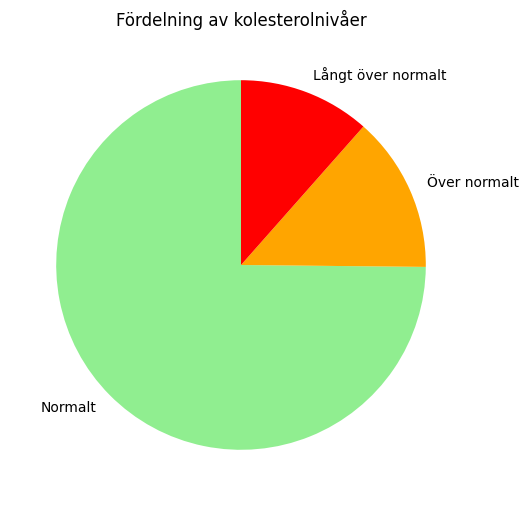

In [ ]:
from helpers import chol_value_report

chol_counts = chol_value_report(df, "cholesterol", labels=["Normalt", "Över normalt", "Långt över normalt"])
plot_pie_chart(chol_counts, ["Normalt", "Över normalt", "Långt över normalt"], "Fördelning av kolesterolnivåer")


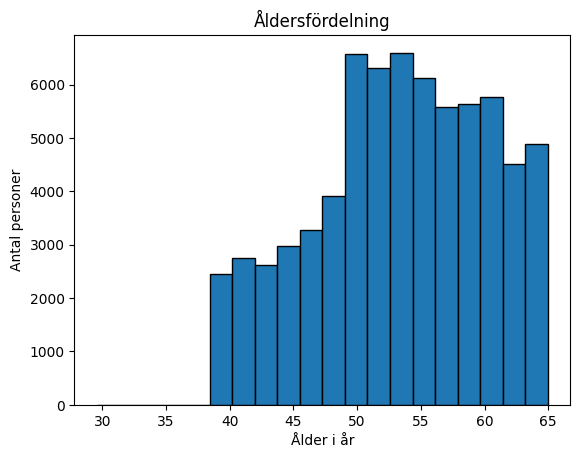

In [5]:
# Hur såg ålderfördelningen ut?

df["age_years"] = df["age"] / 365
plot_histogram(df, "age_years", bins=20, xlabel="Ålder i år", ylabel="Antal personer", title="Åldersfördelning")


Antal rökare: 6169


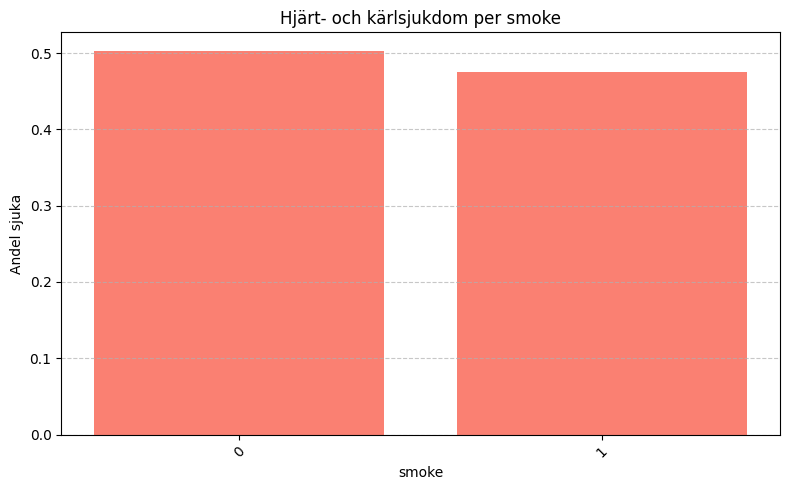

In [6]:
# Hur många rökte?

df_smokers = df[df["smoke"] == 1]
print(f"Antal rökare: {len(df_smokers)}")

# Nedan visualiserades datan över om individer med hjärt- och kärlsjukdomar rökte eller inte.
# 1 betydde att de rökte medan 0 betydde att de inte rökte.
plot_cardio_by_category(df, "smoke")

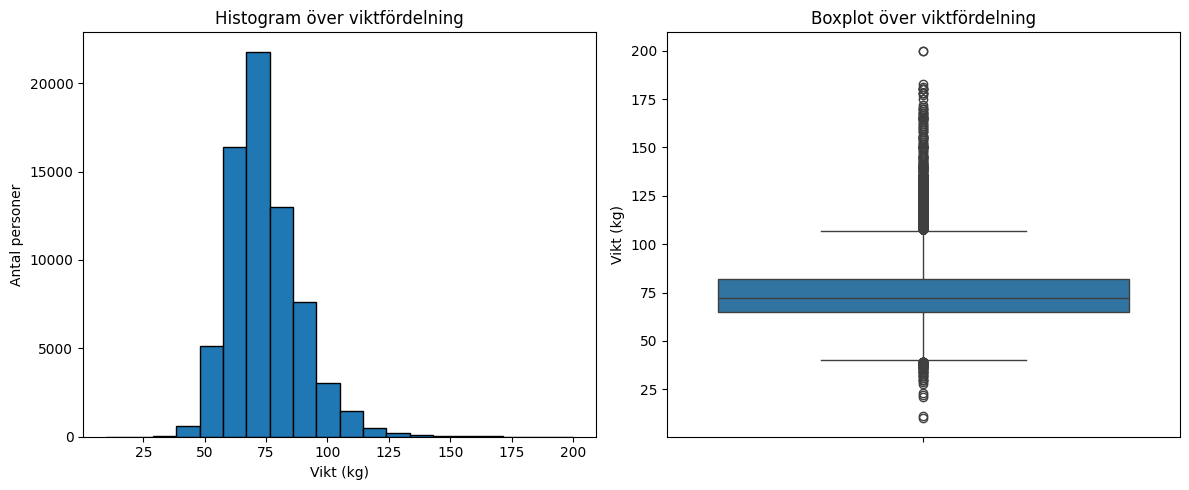

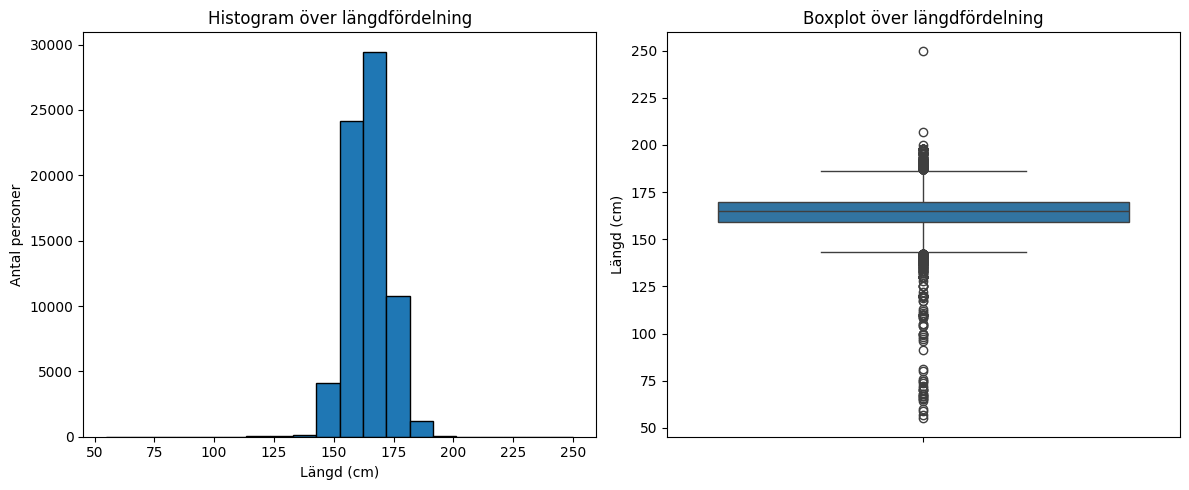

In [7]:
# Hur ser viktfördelningen samt längdfördelningen ut?

plot_dual_hist_box(df, "weight", xlabel="Vikt (kg)", title="viktfördelning")
plot_dual_hist_box(df, "height", xlabel="Längd (cm)", title="längdfördelning")


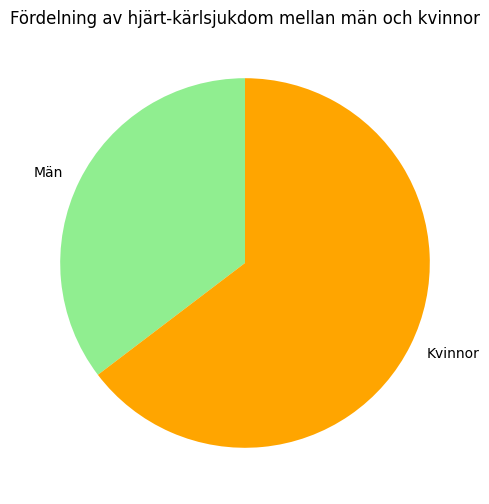

In [8]:
# Hur såg fördelningen av hjärt- och kärlsjukdomar ut mellan män och kvinnor?

df_men = df[(df["cardio"] == 1) & (df["gender"] == 2)]
df_women = df[(df["cardio"] == 1) & (df["gender"] == 1)]
plot_pie_chart([len(df_men), len(df_women)], ["Män", "Kvinnor"], "Fördelning av hjärt-kärlsjukdom mellan män och kvinnor")


## Feature Engineering: BMI

För att beräkna BMI för varje individ i datasetet genomfördes feature engineering.

### **Beräkning av BMI**

Formeln för BMI definieras som:

$BMI = \frac{\text{vikt (kg)}}{\text{längd (m)}^2}$

Eftersom längduppgifterna i datasetet var angivna i centimeter konverterades dessa till meter för att matcha BMI-formelns krav. Därefter beräknades BMI-värdena för varje individ.

### **Kategorisering av BMI**

För att analysera fördelningen av BMI delades värdena in i följande kategorier:

    Normalvikt: 18.5 - 24.9
    Övervikt: 25 - 29.9
    Fetma klass 1: 30 - 34.9
    Fetma klass 2: 35 - 39.9
    Fetma klass 3: > 40

Fördelningen visualiserades med hjälp av stapeldiagram och cirkeldiagram.    

**Källor**

BMI-formel: [Wikipedia](https://en.wikipedia.org/wiki/Body_mass_index)

Val av BMI-gränser:

[ENN Online](https://www.ennonline.net/fex/15/en/limits-human-starvation)

[Wikipedia - List of heaviest people](https://en.wikipedia.org/wiki/List_of_heaviest_people)

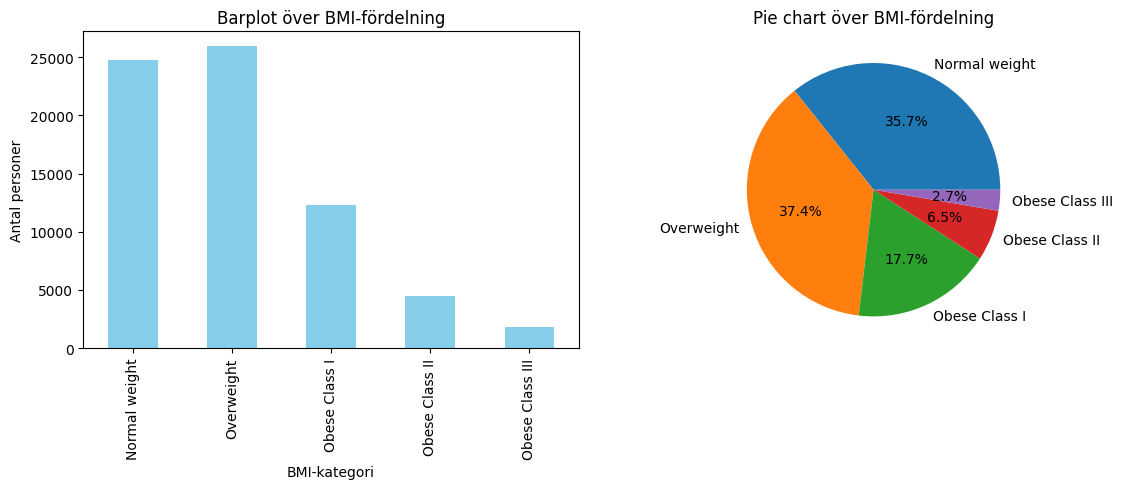

/home/alex/iths/Machine-learning-AI24/labs/lab_1/main/helpers.py:98: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(column)["cardio"].mean()


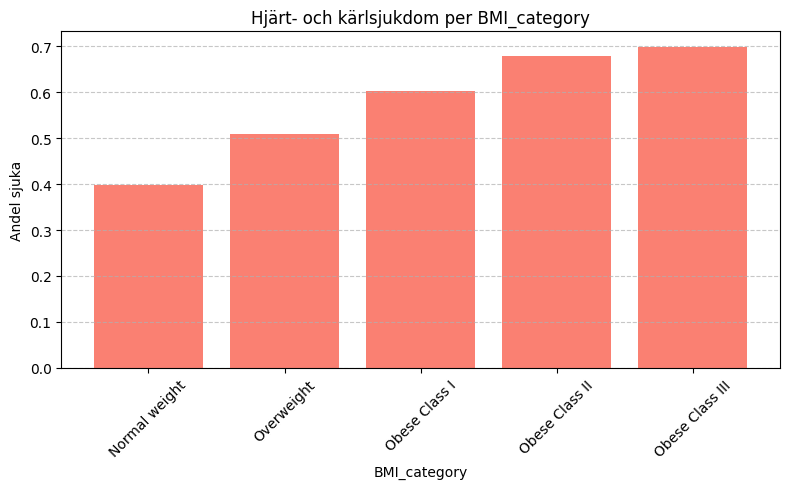

In [9]:
# Hur såg BMI-fördelningen ut?

# Först räknades BMI ut
df = calculate_bmi(df)

# BMI-värden över eller under vissa värden togs bort:
    # Värden under 10 togs bort då de bör vara felaktiga på grund av hur låga de är. BMI under 10 kan förekomma i vissa sällsynta fall av svält i kvinnor, men bör inte förekomma i detta dataset.
    # Värden över 60 togs bort då BMI över 60 är extremt ovanligt och kan vara felaktiga i datasetet. De kan förekomma men då är det i samband med extrem fetma.
df = filter_bmi(df)

# Därefter kategoriserades varje individ in i en BMI-kategori
df = categorize_bmi(df)

# Till sist så visualiserades datan över BMI-fördelning med både en barplot och en piechart, samt sambandet mellan BMI och hjärt- och kärlsjukdomar.
plot_bmi_distribution(df)
plot_cardio_by_category(df, "BMI_category")


## Feature Engineering: Blodtryck

För att hantera blodtrycksdata i datasetet genomfördes feature engineering för att filtrera ut orimliga värden och kategorisera blodtrycksnivåer.

### **Filtrering av orimliga värden**
Blodtrycket var uppdelat i **systoliskt blodtryck** (`ap_hi`) och **diastoliskt blodtryck** (`ap_lo`). För att säkerställa att data var realistisk togs värden utanför följande intervall bort:

- **Systoliskt blodtryck (ap_hi):** 60 - 300 mmHg  
- **Diastoliskt blodtryck (ap_lo):** 30 - 200 mmHg  

Dessa gränser valdes baserat på medicinska riktlinjer:

- [Healthline – Högt blodtryck](https://www.healthline.com/health/high-blood-pressure-hypertension#symptoms)
- [National Heart, Lung, and Blood Institute – Lågt blodtryck](https://www.nhlbi.nih.gov/health/low-blood-pressure)

### **Kategorisering av blodtrycksnivåer**
Efter filtrering delades blodtrycket in i kategorier enligt etablerade medicinska riktlinjer:

- **Healthy:** ap_hi < 120 och ap_lo < 80  
- **Elevated:** ap_hi 120-129 och ap_lo < 80  
- **Stage 1 Hypertension:** ap_hi 130-139 eller ap_lo 80-89  
- **Stage 2 Hypertension:** ap_hi 140-180 eller ap_lo 90-120  
- **Hypertensive Crisis:** ap_hi > 180 eller ap_lo > 120  

Kategoriseringen implementerades genom att applicera en funktion på datasetet, där varje individ tilldelades en blodtryckskategori.

### **Verifiering av resultat**
Slutligen granskades ett urval av datasetet för att säkerställa att kategoriseringen av blodtryck hade genomförts korrekt.


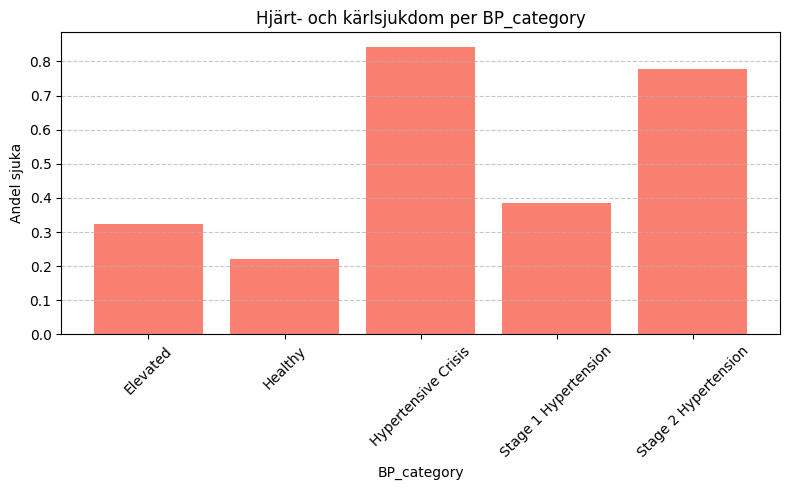

In [10]:
# Hur såg blodtrycksfördelningen ut?

# Först så filtrerades blodtrycksvärden som ansågs vara orealistiskt höga eller låga bort.
df = filter_blood_pressure(df)

# Funktionen apply_bp_category användes för att kategorisera blodtrycksvärdena i olika kategorier.
df = apply_bp_category(df)


# Till sist visualiserades sambandet mellan de olika BP-kategorierna och hjärt- och kärlsjukdomar.
plot_cardio_by_category(df, "BP_category")






## Analys av hjärt- och kärlsjukdomar i datasetet

För att analysera hur olika faktorer påverkar risken för hjärt- och kärlsjukdomar genomfördes en statistisk undersökning där förekomsten av hjärtsjukdom beräknades för olika grupper inom datasetet. Genom att gruppera individer baserat på specifika hälsovariabler kunde mönster identifieras och visualiseras.

#### Beräkning av andelen sjuka per kategori

Följande kategorier undersöktes:

    Blodtryckskategorier (BP_category)
    BMI-kategorier (BMI_category)
    Kolesterolnivåer (cholesterol)
    Rökning (smoke)
    Ålder (age_years)

Barplots genererades för att visa hur andelen med hjärt- och kärlsjukdom varierade mellan olika grupper.

En korrelationsmatris genererades även för att undersöka sambanden mellan numeriska variabler.





/home/alex/iths/Machine-learning-AI24/labs/lab_1/main/helpers.py:157: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cardio_chol = df.groupby("cholesterol_label")["cardio"].mean()


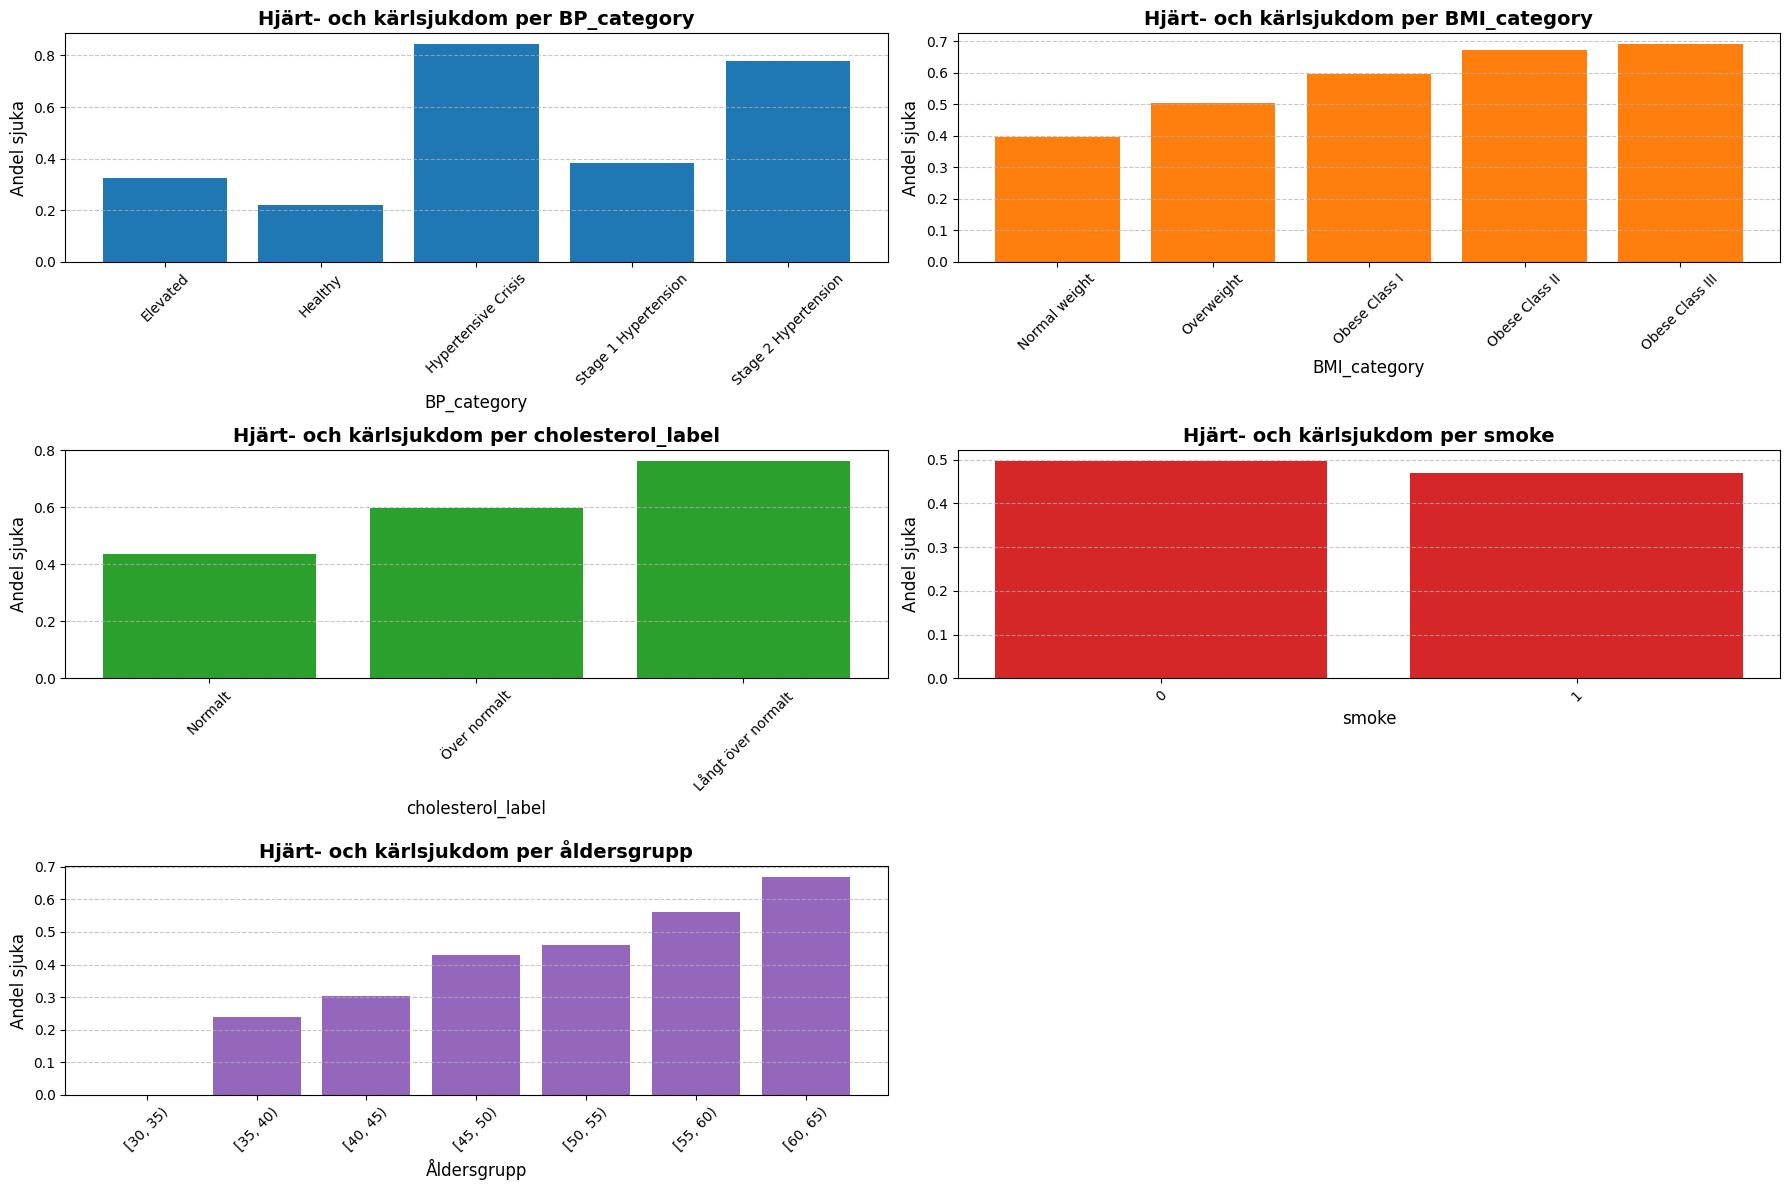

In [11]:
plot_multiple_cardio_categories(df)

In [12]:
# Nedan skapades en korrelationsmatris för att se hur de olika features korrelerar med varandra.

correlation_matrix = df.corr(numeric_only=True)
print(correlation_matrix)


                   id       age    gender    height    weight     ap_hi  \
id           1.000000  0.003501  0.003107 -0.003438 -0.001775  0.001303   
age          0.003501  1.000000 -0.023131 -0.084572  0.055224  0.208708   
gender       0.003107 -0.023131  1.000000  0.514169  0.157904  0.061439   
height      -0.003438 -0.084572  0.514169  1.000000  0.310484  0.019322   
weight      -0.001775  0.055224  0.157904  0.310484  1.000000  0.269377   
ap_hi        0.001303  0.208708  0.061439  0.019322  0.269377  1.000000   
ap_lo       -0.000608  0.152626  0.066544  0.036796  0.249302  0.696851   
cholesterol  0.005892  0.155515 -0.036624 -0.053863  0.142351  0.193952   
gluc         0.002272  0.099149 -0.021055 -0.020564  0.107722  0.092575   
smoke       -0.003332 -0.047841  0.338760  0.194170  0.067374  0.027159   
alco         0.000669 -0.029014  0.170952  0.097807  0.068528  0.032517   
active       0.003753 -0.010512  0.005929 -0.008454 -0.018393 -0.001336   
cardio       0.003779  0.

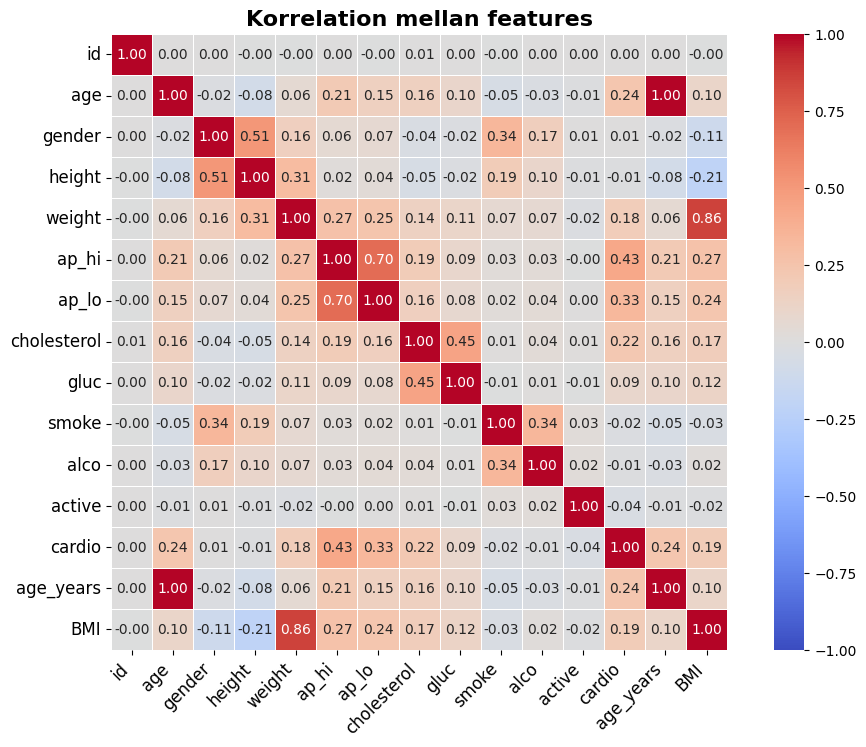

In [13]:
# En heatmap skapades för att visualisera korrelationen mellan features.

plot_heatmap(correlation_matrix)


## Korrelation mellan variabler och hjärt- och kärlsjukdomar

Analysen av korrelationer i heatmappen identifierade flera samband mellan olika faktorer och förekomsten av hjärt- och kärlsjukdomar.

#### Blodtryck (ap_hi och ap_lo) och hjärt- och kärlsjukdomar

En tydlig positiv korrelation observerades mellan systoliskt blodtryck (ap_hi), diastoliskt blodtryck (ap_lo) och förekomsten av hjärt- och kärlsjukdomar (cardio). Högt blodtryck är en känd riskfaktor för hjärt-kärlsjukdomar, vilket bekräftades av resultatet.

#### Ålder, kolesterol och BMI som riskfaktorer

En positiv korrelation identifierades mellan ålder och hjärtsjukdomar, vilket kan förklaras av att äldre individer ofta har en ökad förekomst av riskfaktorer såsom högt blodtryck, kolesterol och metabola sjukdomar. Dessutom visade kolesterolnivåer och BMI en positiv koppling till hjärtsjukdom, vilket stöder befintliga medicinska insikter om att höga kolesterolnivåer och fetma är betydande riskfaktorer.

#### Stark korrelation mellan systoliskt och diastoliskt blodtryck

En hög korrelation (0.7) mellan ap_hi och ap_lo noterades, vilket är förväntat eftersom dessa två blodtrycksvärden tenderar att förändras samtidigt.

#### Samband mellan glukos och kolesterol

En måttlig korrelation identifierades mellan glukosnivåer (gluc) och kolesterol (cholesterol). En möjlig förklaring är att båda faktorer kan påverkas av ohälsosamma kostvanor och metabola syndrom, vilket kan öka risken för både diabetes och hjärtsjukdomar.

#### Låg korrelation mellan fysisk aktivitet och hjärtsjukdomar

Förvånansvärt nog observerades en låg korrelation mellan fysisk aktivitet (active) och hjärt- och kärlsjukdomar. En förväntad skyddande effekt av fysisk aktivitet kunde inte bekräftas i denna analys, vilket kan indikera att andra faktorer, såsom kost och genetik, spelar en större roll i detta dataset.



## Feature Engineering

Två olika dataset skapades för modellering:

- `df1` bestod av kategoriserade versioner av variabler som BMI och blodtryck.
- `df2` behöll de ursprungliga numeriska värdena.

Kategoriska variabler konverterades till dummy-variabler för att kunna användas i maskininlärningsmodeller.

Varje dataset delades upp i tre delar: träningsdata (80 %), valideringsdata (10 %) och testdata (10 %). Denna uppdelning användes för att träna modeller, välja bästa parametrar och utvärdera slutresultatet.

Alla numeriska features standardiserades och normaliserades med hjälp av `StandardScaler` och `MinMaxScaler`. Detta steg förbättrade prestandan för modeller som är känsliga för skillnader i skala, såsom KNN och SVM.

In [ ]:
df1, df2 = create_feature_sets(df)

X_train1, X_val1, X_test1, y_train1, y_val1, y_test1 = split_data(df1)
X_train2, X_val2, X_test2, y_train2, y_val2, y_test2 = split_data(df2)

X_train_scaled_1, X_val_scaled_1, X_test_scaled_1 = scale_data(X_train1, X_val1, X_test1)
X_train_scaled_2, X_val_scaled_2, X_test_scaled_2 = scale_data(X_train2, X_val2, X_test2)


## Modellträning och hyperparameteroptimering

Flera olika klassificeringsmodeller testades: `Logistic Regression`, `K-Nearest Neighbors`, `Support Vector Classifier` och `Random Forest`.

För varje modell kördes en `GridSearchCV` för att hitta de bästa hyperparametrarna. Optimeringen gjordes med `recall` som scoring-mått.

Modellerna utvärderades baserat på deras `accuracy` på valideringsdatan. Resultaten visualiserades i en stapeldiagram för att jämföra deras prestanda.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# "Param grids" skapades för att användas i GridSearchCV, vilket själv användes i train_all_models, för att hitta de bästa hyperparametrarna för varje modell.

models = {
    "Logistic Regression": LogisticRegression,
    "KNN": KNeighborsClassifier,
    "LinearSVC": LinearSVC,
    "Random Forest": RandomForestClassifier
}


param_grids = {
    "Logistic Regression": {
        "C": [0.001, 0.01, 0.1, 1, 10, 100],
        "solver": ["liblinear", "lbfgs", "saga"],
        "penalty": ["l2"], 
        "max_iter": [10000]
    },
    "KNN": {
        "n_neighbors": [3, 5, 7],
        "weights": ["uniform", "distance"],
        "metric": ["euclidean", "manhattan"]
    },
    "LinearSVC": {
        "C": [0.1, 1, 10],
        "dual": [False],
        "max_iter": [1000]
    },
    "Random Forest": {
        "n_estimators": [50, 100],
        "max_depth": [None, 10],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2]
    }
}

best_models = train_all_models(models, param_grids, X_train_scaled_1, y_train1, X_train_scaled_2, y_train2)
results_df = evaluate_models(best_models, X_val_scaled_1, y_val1, X_val_scaled_2, y_val2)
print(results_df)


🔍 Tränar Logistic Regression på dataset 1...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Bästa parametrar för Logistic Regression: {'C': 10, 'max_iter': 10000, 'penalty': 'l2', 'solver': 'lbfgs'}
Bästa validerings-score: 0.6489

🔍 Tränar Logistic Regression på dataset 2...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Bästa parametrar för Logistic Regression: {'C': 0.1, 'max_iter': 10000, 'penalty': 'l2', 'solver': 'lbfgs'}
Bästa validerings-score: 0.6682

🔍 Tränar KNN på dataset 1...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Bästa parametrar för KNN: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}
Bästa validerings-score: 0.6848

🔍 Tränar KNN på dataset 2...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Bästa parametrar för KNN: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}
Bästa validerings-score: 0.6719

🔍 Tränar LinearSVC på dataset 1...
Fitting 5 folds for each of 3 candidates, to

In [ ]:
# Prediktioner gjordes med de bästa modellerna för varje dataset.
from helpers import predict_with_models
val_predictions = predict_with_models(best_models, X_val_scaled_1, X_val_scaled_2)

Gör prediction med Logistic Regression_df1...
Gör prediction med Logistic Regression_df2...
Gör prediction med KNN_df1...
Gör prediction med KNN_df2...
Gör prediction med LinearSVC_df1...
Gör prediction med LinearSVC_df2...
Gör prediction med Random Forest_df1...
Gör prediction med Random Forest_df2...


## Modellutvärdering

De bästa modellerna från GridSearch utvärderades på valideringsdata med `accuracy` som mått. 

Resultaten presenterades i en tabell och en horisontell barplot.


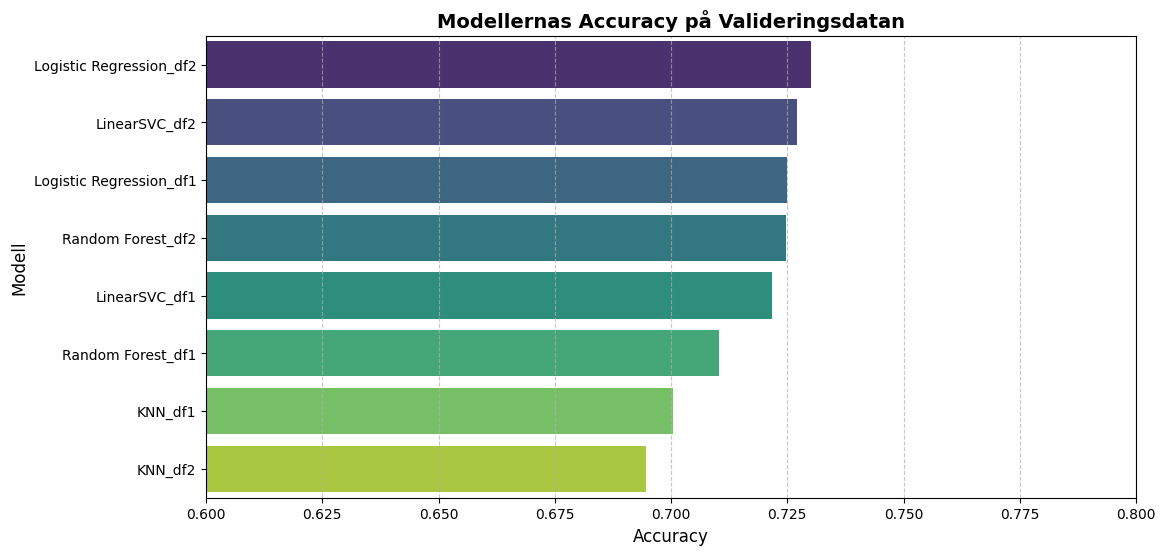

In [ ]:
results_df = evaluate_models(best_models, X_val_scaled_1, y_val1, X_val_scaled_2, y_val2)
plot_evaluation_results(results_df)

In [ ]:
# De bästa parametrarna för varje modell skrevs sedan ut.
from helpers import extract_best_params

best_param_dict = extract_best_params(best_models, param_grids)

Bästa parametrar för Logistic Regression_df1: {'C': 10, 'max_iter': 10000, 'penalty': 'l2', 'solver': 'lbfgs'}
Bästa parametrar för Logistic Regression_df2: {'C': 0.1, 'max_iter': 10000, 'penalty': 'l2', 'solver': 'lbfgs'}
Bästa parametrar för KNN_df1: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}
Bästa parametrar för KNN_df2: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}
Bästa parametrar för LinearSVC_df1: {'C': 1, 'dual': False, 'max_iter': 1000}
Bästa parametrar för LinearSVC_df2: {'C': 0.1, 'dual': False, 'max_iter': 1000}
Bästa parametrar för Random Forest_df1: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Bästa parametrar för Random Forest_df2: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}


## Ensemblemodell (Voting Classifier)

För varje dataset skapades en `VotingClassifier` som kombinerade de bästa versionerna av alla fyra modeller.

Modellerna tränades och utvärderades för att avgöra vilken ensemble som presterade bäst.


In [ ]:
from helpers import create_voting_classifiers

vote_clf_df1, vote_clf_df2 = create_voting_classifiers(best_models)


In [22]:
from helpers import train_voting_classifiers

# Modellerna tränades på respektive träningsdata.

vote_clf_df1, vote_clf_df2 = train_voting_classifiers(vote_clf_df1, vote_clf_df2, X_train_scaled_1, y_train1, X_train_scaled_2, y_train2)




🔍 Tränar VotingClassifier på dataset 1...
🔍 Tränar VotingClassifier på dataset 2...


In [23]:
from helpers import evaluate_voting_classifiers

# Prediktioner gjordes med VotingClassifier för varje dataset.
# evaluate_voting_classifiers användes sedan för att utvärdera modellerna och det dataset med högst accuracy valdes.

chosen_dataset, (acc1, acc2) = evaluate_voting_classifiers(vote_clf_df1, vote_clf_df2, X_val_scaled_1, y_val1, X_val_scaled_2, y_val2)


Accuracy för VotingClassifier på df1: 0.7203
Accuracy för VotingClassifier på df2: 0.7284
Valt dataset: df2


In [24]:
from helpers import get_best_model_name
# Den bästa modellen valdes också ut.

results_df = evaluate_models(best_models, X_val_scaled_1, y_val1, X_val_scaled_2, y_val2)
best_model_name = get_best_model_name(results_df)


Bästa enskilda modellen: Logistic Regression_df2


## Slutlig modell och optimering av tröskelvärde

Den bästa `Logistic Regression`-modellen tränades på både tränings- och valideringsdatan. Prediktioner för testdatan genererades, och olika tröskelvärden (0.5, 0.4, 0.3) testades för att optimera antalet korrekta positiva (True Positives).

Den confusion matrix som gav högst antal korrekt klassificerade sjuka valdes, och resultatet presenterades tillsammans med `precision`, `recall` och `f1-score`.



Bästa tröskelvärdet: 0.3
              precision    recall  f1-score   support

           0       0.82      0.37      0.51      3496
           1       0.58      0.91      0.71      3376

    accuracy                           0.64      6872
   macro avg       0.70      0.64      0.61      6872
weighted avg       0.70      0.64      0.61      6872



(0.3, array([1, 1, 1, ..., 1, 1, 1]))

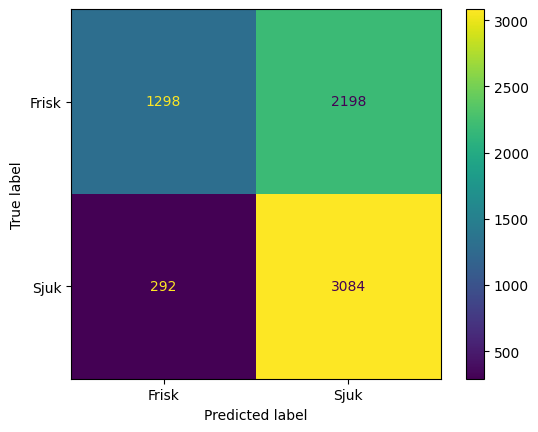

In [ ]:
from helpers import optimize_threshold

final_model = LogisticRegression(**best_models["Logistic Regression_df2"].get_params())
optimize_threshold(
    final_model,
    X_train_scaled_2, y_train2,
    X_val_scaled_2, y_val2,
    X_test_scaled_2, y_test2
)

## Slutsats

I denna labb användes maskininlärningsmetoder för att analysera ett dataset relaterat till hjärt- och kärlsjukdomar. Syftet var att förutsäga sjukdomstillstånd baserat på olika hälsorelaterade variabler samt att optimera en prediktiv modell genom tröskeljustering.

#### Databearbetning och Feature Engineering:

Orimliga värden för blodtryck och BMI rensades bort för att förbättra datakvaliteten.

Blodtryck och BMI kategoriserades enligt etablerade medicinska riktlinjer för att möjliggöra enklare tolkning och förbättrad modellprestanda.

En korrelationsanalys visade att blodtryck och ålder hade den starkaste kopplingen till förekomsten av hjärt- och kärlsjukdom.

#### Modellutvärdering:

Flera maskininlärningsmodeller testades, där Random Forest och Logistisk Regression visade bäst prestanda.

Hyperparameteroptimering genomfördes med GridSearchCV för att förbättra modellerna ytterligare.

Även en VotingClassifier testades för att kombinera flera modeller, men valdes inte som slutgiltigt alternativ.

#### Optimering av tröskelvärde:

Den slutgiltiga modellen tränades på både tränings- och valideringsdata, och en tröskeloptimering genomfördes.

Det bästa tröskelvärdet identifierades till 0.3, vilket ledde till en mycket hög återkallelse (recall) för den positiva klassen (91%).

Detta innebar att de flesta sjuka patienter identifierades korrekt, vilket är av särskild vikt i medicinska sammanhang.

Samtidigt ökade andelen falskt positiva – det vill säga friska som felaktigt klassificerades som sjuka – vilket kan leda till onödiga medicinska uppföljningar, men är ofta acceptabelt för att minimera risken att missa verkliga fall.

#### Slutlig bedömning

Den valda modellen (Logistisk Regression) visade sig vara det bästa alternativet i denna kontext.

Genom att prioritera hög recall minskades risken för falskt negativa fall, vilket är centralt vid screening för allvarliga sjukdomar.

Att hellre ge falskt positiva varningar än att missa verkliga fall bör prioriteras inom sjukvården.
Därför ansågs denna modell lämpa sig väl för det aktuella syftet.
